In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH
from neuron_custom_features import calc_spines_features
from spines_utils import filter_valid_neuron_w_spines
from plot_utils import ex_color, inh_color, ei_palette
from stats_corr import add_reg_line
from figures_utils import add_panel_label

In [3]:
neurons_df = load_neurons_table(use_column_manual_ct=True)
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

ex_df = df[df.clf_type == 'E']
inh_df = df[df.clf_type == 'I']

# remove 1 outlier
df = df[df.ds_num_of_incoming_synapses < 25000].copy()
ex_df = df[df.clf_type == 'E']
inh_df = df[df.clf_type == 'I']

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:13<00:00, 100.52it/s]


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


In [4]:
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Arial'

meanprops = {"marker": "o", "markerfacecolor": "white",
             "markeredgecolor": "black", "markersize": "5"}
features_small_font_size = 12

R=0.89 R^2: 0.80 slope: 0.21 intercept: -0.01, p=p=4.3e-56
R=0.97 R^2: 0.95 slope: 0.69 intercept: -0.01, p=p=1.7e-101
R=0.85 R^2: 0.71 slope: 0.63 intercept: -0.02, p=p=2.3e-311
R=0.39 R^2: 0.16 slope: 0.17 intercept: 0.01, p=p=9.9e-44


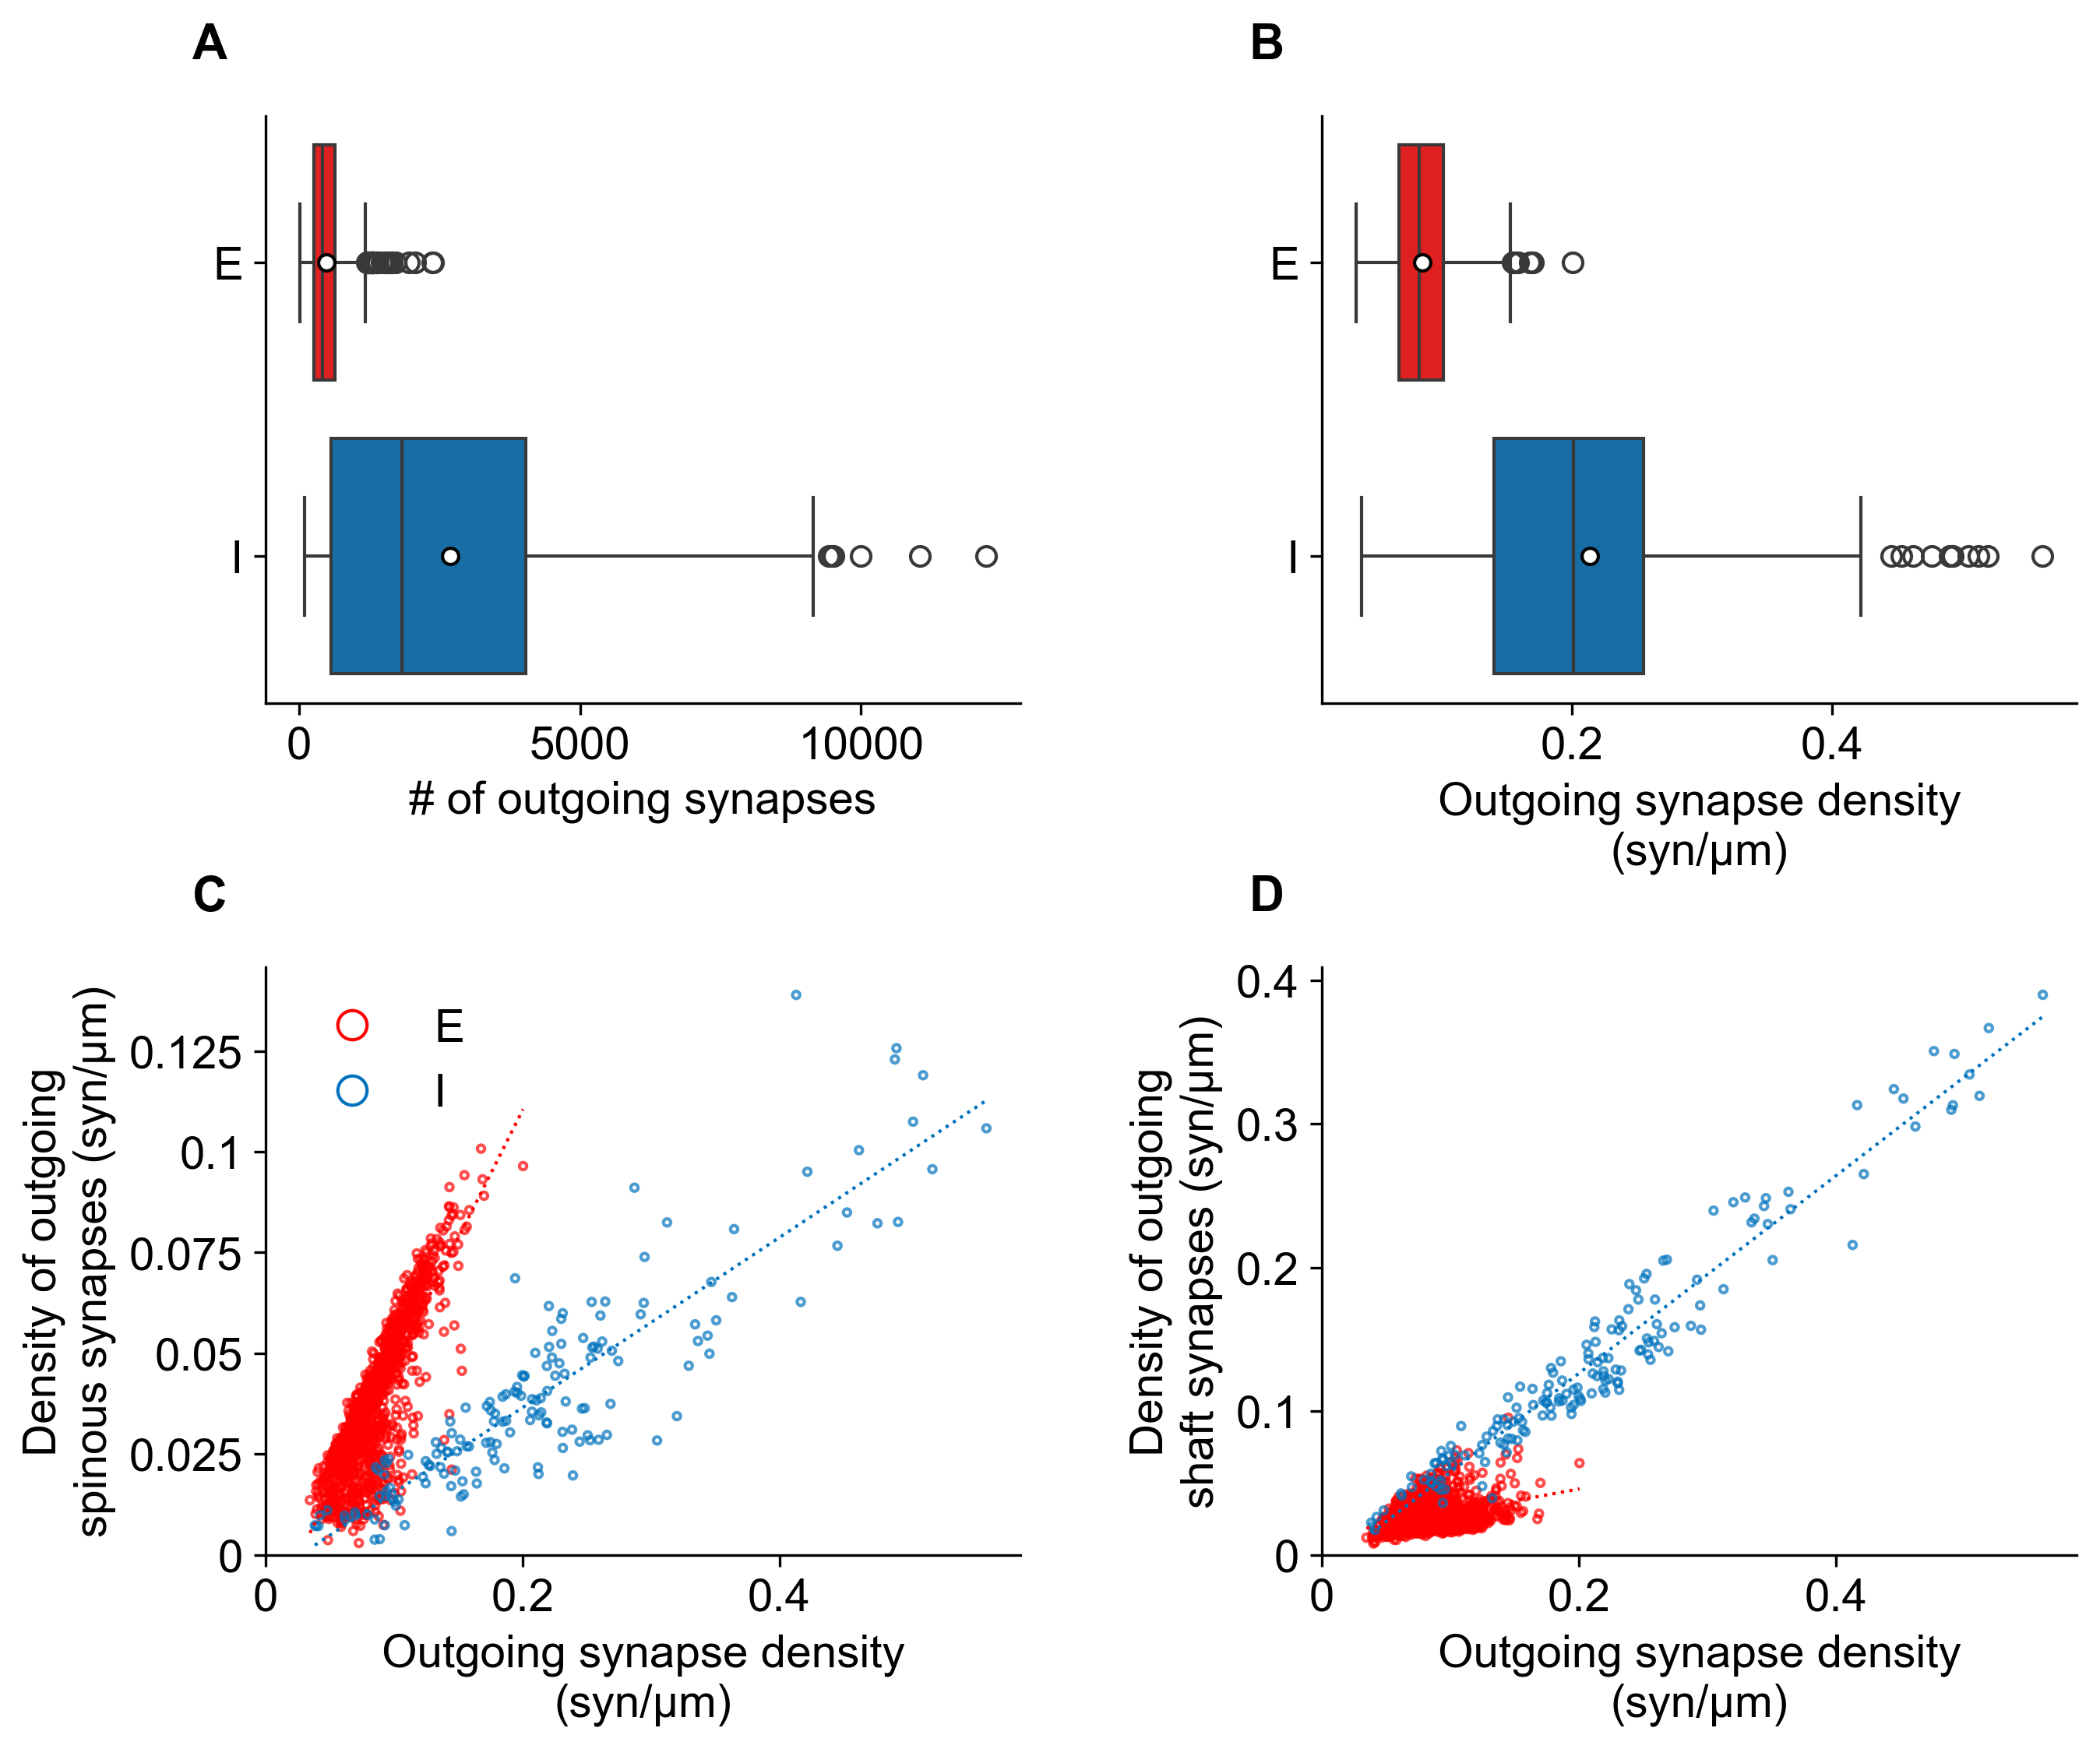

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300)
axes = axes.flatten()
axes[3].sharex(axes[2])

sns.boxplot(data=df, y='clf_type', x='ds_num_of_outgoing_synapses', palette=ei_palette,
            hue='clf_type', ax=axes[0], showfliers=True, showmeans=True, meanprops=meanprops)
axes[0].set_xlabel('# of outgoing synapses')

sns.boxplot(data=df, y='clf_type', x='ds_outgoing_synapses_density', palette=ei_palette,
            hue='clf_type', ax=axes[1], showfliers=True, showmeans=True, meanprops=meanprops)
axes[1].set_xlabel('Outgoing synapse density\n(syn/\u03bcm)')

point_colors = df['clf_type'].map(ei_palette)
axes[2].scatter(x=df['ds_outgoing_synapses_density'], y=df['ds_outgoing_spine_density'],
                edgecolors=point_colors, facecolors='none', s=5, alpha=0.7)
axes[3].scatter(x=df['ds_outgoing_synapses_density'], y=df['ds_outgoing_shaft_density'],
                edgecolors=point_colors, facecolors='none', s=5, alpha=0.7)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markeredgecolor=ei_palette['E'],
           markerfacecolor='none', markersize=9, label='E'),
    Line2D([0], [0], marker='o', linestyle='none', markeredgecolor=ei_palette['I'],
           markerfacecolor='none', markersize=9, label='I')
]
axes[2].legend(handles=legend_handles, title='', frameon=False)

add_reg_line(inh_neurons['ds_outgoing_synapses_density'], inh_neurons['ds_outgoing_spine_density'], ax=axes[2], color=inh_color)
add_reg_line(inh_neurons['ds_outgoing_synapses_density'], inh_neurons['ds_outgoing_shaft_density'], ax=axes[3], color=inh_color)
add_reg_line(ex_neurons['ds_outgoing_synapses_density'], ex_neurons['ds_outgoing_spine_density'], ax=axes[2], color=ex_color)
add_reg_line(ex_neurons['ds_outgoing_synapses_density'], ex_neurons['ds_outgoing_shaft_density'], ax=axes[3], color=ex_color)

for ax in [axes[2], axes[3]]:
    if ax.get_legend() is not None:
        sns.move_legend(ax, loc='upper left', title='', frameon=False)

axes[2].set_ylabel('Density of outgoing\nspinous synapses (syn/\u03bcm)')
axes[3].set_ylabel('Density of outgoing\nshaft synapses (syn/\u03bcm)')
axes[3].set_xlabel('Outgoing synapse density\n(syn/\u03bcm)')
axes[2].set_xlabel('Outgoing synapse density\n(syn/\u03bcm)')

for ax in [axes[0], axes[1]]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_ylabel('')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in [axes[2], axes[3]]:
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=0)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))

add_panel_label(axes[0], 'A', xy=(-0.05, 1.08), fontsize=15)
add_panel_label(axes[1], 'B', xy=(-0.05, 1.08), fontsize=15)
add_panel_label(axes[2], 'C', xy=(-0.05, 1.08), fontsize=15)
add_panel_label(axes[3], 'D', xy=(-0.05, 1.08), fontsize=15)

plt.subplots_adjust(hspace=0.45, wspace=0.4)
plt.savefig('fig_s5.pdf', format='pdf', bbox_inches='tight')